# Avance 3. Baseline - Avocado AI

**Proyecto:** Monitoreo de estres hidrico en huertos de aguacate con imagenes multitemporales Sentinel-2 e inteligencia artificial.  
**Equipo:** 19  
**Entregable:** `Avance3.Equipo19`  
**Notebook:** baseline reproducible para evaluar la viabilidad del problema y fijar una referencia para modelos posteriores.

Este avance sigue la arquitectura propuesta por el equipo: descarga/procesamiento Sentinel-2, calculo de indices espectrales, clasificacion de estres por parcela y analisis multitemporal. Para el baseline se usa el dataset tabular construido en el Avance 2, porque ya contiene indices espectrales, variables temporales, rezagos, promedios moviles, PCA/FA y etiquetas proxy de estres.

> Nota metodologica: las etiquetas `stress_label` parecen ser una aproximacion derivada de indices espectrales, no mediciones de campo. Por tanto, este baseline mide si las variables satelitales reproducen de forma consistente una regla operacional de estres relativo. Para despliegue agronomico se debe validar contra observaciones de campo, riego, humedad de suelo o diagnostico experto.

## 1. Requerimientos del Avance 3

Preguntas que aborda la libreta:

1. **Algoritmo baseline:** se propone una regresion logistica multinomial regularizada con pesos por clase, comparada contra un clasificador ingenuo.
2. **Caracteristicas importantes:** se usan coeficientes del modelo y `permutation_importance` para interpretar que variables sostienen la prediccion.
3. **Sub/sobreajuste:** se comparan metricas en entrenamiento, prueba, validacion cruzada por parcela y curva de aprendizaje.
4. **Metrica:** se usa `F1 macro` como metrica principal por el desbalance de clases; tambien se reportan `balanced_accuracy` y recall de la clase severa.
5. **Desempeno minimo:** el baseline debe superar claramente al azar/estrategia mayoritaria y recuperar la mayor parte de los casos severos.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    recall_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_PATH = PROJECT_ROOT / 'notebooks' / 'df_fe_avance2.csv'
RAW_MONTHLY_PATH = PROJECT_ROOT / 'notebooks' / 'data' / 'csv' / 'aguacates_jalisco_monthly_indices_2023_2026.csv'
PROCESSED_INDICES_PATH = PROJECT_ROOT / 'notebooks' / 'processed' / 'indices_imputados.csv'
GEOTIFF_DIR = PROJECT_ROOT / 'notebooks' / 'data' / 'geotiff'

print('Proyecto:', PROJECT_ROOT)
print('Dataset FE:', DATASET_PATH, DATASET_PATH.exists())
print('GeoTIFFs:', GEOTIFF_DIR, GEOTIFF_DIR.exists())

Proyecto: C:\Users\YOLOA\OneDrive\Desktop\Repo Proyecto Integrador\Avocado AI
Dataset FE: C:\Users\YOLOA\OneDrive\Desktop\Repo Proyecto Integrador\Avocado AI\notebooks\df_fe_avance2.csv True
GeoTIFFs: C:\Users\YOLOA\OneDrive\Desktop\Repo Proyecto Integrador\Avocado AI\notebooks\data\geotiff True


## 2. Carga y entendimiento rapido de datos

El archivo principal es `notebooks/df_fe_avance2.csv`. Si no estuviera disponible, la libreta incluye un respaldo para construir una version minima desde el CSV mensual de NDVI/NDMI. En condiciones normales se usa el dataset del Avance 2 porque ya contiene ingenieria de caracteristicas y clases de estres.

In [2]:
def build_minimal_dataset_from_monthly(path: Path) -> pd.DataFrame:
    """Fallback reproducible si no existe el dataset de FE.

    Crea etiquetas proxy por terciles de NDMI: bajo estres relativo, estres moderado y estres severo.
    Esta ruta no reemplaza el Avance 2; solo mantiene ejecutable el notebook.
    """
    monthly = pd.read_csv(path)
    monthly['date'] = pd.to_datetime(monthly['date'])
    monthly = monthly.sort_values(['name', 'date']).reset_index(drop=True)
    monthly['NDVI_roll3'] = monthly.groupby('name')['NDVI'].transform(lambda s: s.rolling(3, min_periods=1).mean())
    monthly['NDMI_roll3'] = monthly.groupby('name')['NDMI'].transform(lambda s: s.rolling(3, min_periods=1).mean())
    monthly['NDVI_lag1'] = monthly.groupby('name')['NDVI'].shift(1)
    monthly['NDVI_lag2'] = monthly.groupby('name')['NDVI'].shift(2)
    monthly['NDMI_lag2'] = monthly.groupby('name')['NDMI'].shift(2)
    monthly['NDVI_delta'] = monthly.groupby('name')['NDVI'].diff()
    monthly['NDMI_delta'] = monthly.groupby('name')['NDMI'].diff()
    monthly['ratio_vi_hum'] = monthly['NDVI'] / (monthly['NDMI'].abs() + 1e-3)
    monthly['mes_sin'] = np.sin(2 * np.pi * monthly['month'] / 12)
    monthly['mes_cos'] = np.cos(2 * np.pi * monthly['month'] / 12)

    q1, q2 = monthly['NDMI_roll3'].quantile([0.10, 0.25])
    monthly['stress_label'] = np.select(
        [monthly['NDMI_roll3'] <= q1, monthly['NDMI_roll3'] <= q2],
        [2, 1],
        default=0,
    )
    monthly['stress_class'] = monthly['stress_label'].map({
        0: 'no_relative_stress',
        1: 'moderate_possible_stress',
        2: 'severe_possible_stress',
    })
    return monthly

if DATASET_PATH.exists():
    df = pd.read_csv(DATASET_PATH)
    source = DATASET_PATH
else:
    df = build_minimal_dataset_from_monthly(RAW_MONTHLY_PATH)
    source = RAW_MONTHLY_PATH

print('Fuente usada:', source)
print('Forma:', df.shape)
display(df.head())
display(df.dtypes.to_frame('dtype').T)

Fuente usada: C:\Users\YOLOA\OneDrive\Desktop\Repo Proyecto Integrador\Avocado AI\notebooks\df_fe_avance2.csv
Forma: (4000, 36)


,name,date,year,month,stress_class,stress_label,NDMI_sc,NDMI_roll3_sc,NDVI_sc,NDVI_roll3_sc,NDMI_lag2_sc,NDVI_lag1_sc,mes_sin_sc,NDVI_lag2_sc,ratio_vi_hum_log_sc,lat_kml_sc,mes_cos_sc,image_count_sc,lon_kml_sc,NDMI_delta_yj_sc,NDVI_delta_yj_sc,NDWI_proxy_sc,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,FA1,FA2,FA3,FA4,FA5
0,H1,2023-01-01,2023,1,moderate_possible_stress,1,-1.022531,-1.132622,-1.366467,-1.568217,1.208583e-16,0.000000,0.585722,0.000000,-0.270025,2.806674,1.217759,-0.645978,0.455801,0.087816,0.066570,-0.729059,-2.142010,-0.821457,-0.079506,2.315959,0.824626,-0.528796,-0.595188,1.215108,0.754560,1.363864,0.084364,-0.529332,0.516261,-0.152157
1,H1,2023-02-01,2023,2,severe_possible_stress,2,-1.393120,-1.335875,-1.940279,-1.895365,1.208583e-16,-1.389291,1.097147,0.000000,-0.956623,2.806674,0.689877,0.555841,0.455801,-0.603016,-0.691868,-1.109866,-3.345630,-1.633657,-0.837377,2.254094,-0.287318,-1.139819,0.158140,0.813162,0.991438,1.930918,0.208010,0.002388,0.625355,0.067617
2,H1,2023-03-01,2023,3,severe_possible_stress,2,-1.660000,-1.501208,-2.095917,-2.063570,-1.085464e+00,-1.969428,1.284342,-1.413198,-1.209792,2.806674,-0.031225,0.555841,0.455801,-0.395610,-0.121222,-1.001914,-4.861989,-1.032287,-0.195413,1.855410,-0.567896,-1.211701,0.133127,0.753420,0.677914,2.100751,-0.008067,-0.376840,1.286118,0.102725
3,H1,2023-04-01,2023,4,severe_possible_stress,2,-1.676947,-1.740489,-2.269056,-2.406633,-1.467405e+00,-2.126781,1.097147,-1.999392,-1.295650,2.806674,-0.752326,0.555841,0.455801,0.077651,-0.144289,-1.237281,-5.758570,-0.334193,-0.203389,1.733150,-0.748279,-0.956997,0.285888,0.707724,0.375756,2.262711,0.171589,-0.690678,0.942607,0.508462
4,H1,2023-05-01,2023,5,severe_possible_stress,2,-1.783765,-1.883325,-2.250137,-2.524407,-1.742461e+00,-2.301829,0.585722,-2.158389,-1.341357,2.806674,-1.280209,0.555841,0.455801,-0.088270,0.104981,-1.073580,-6.116311,-0.046105,0.208485,1.590789,-0.785895,-1.191560,0.536394,0.444222,-0.091965,2.255483,-0.011091,-0.933756,0.945688,0.619567


,name,date,year,month,stress_class,stress_label,NDMI_sc,NDMI_roll3_sc,NDVI_sc,NDVI_roll3_sc,NDMI_lag2_sc,NDVI_lag1_sc,mes_sin_sc,NDVI_lag2_sc,ratio_vi_hum_log_sc,lat_kml_sc,mes_cos_sc,image_count_sc,lon_kml_sc,NDMI_delta_yj_sc,NDVI_delta_yj_sc,NDWI_proxy_sc,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,FA1,FA2,FA3,FA4,FA5
dtype,object,object,int64,int64,object,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


Parcelas unicas: 100
Rango temporal: 2023-01-01 a 2026-04-01


,conteo
stress_label,
sin estres relativo,3000
estres moderado posible,600
estres severo posible,400


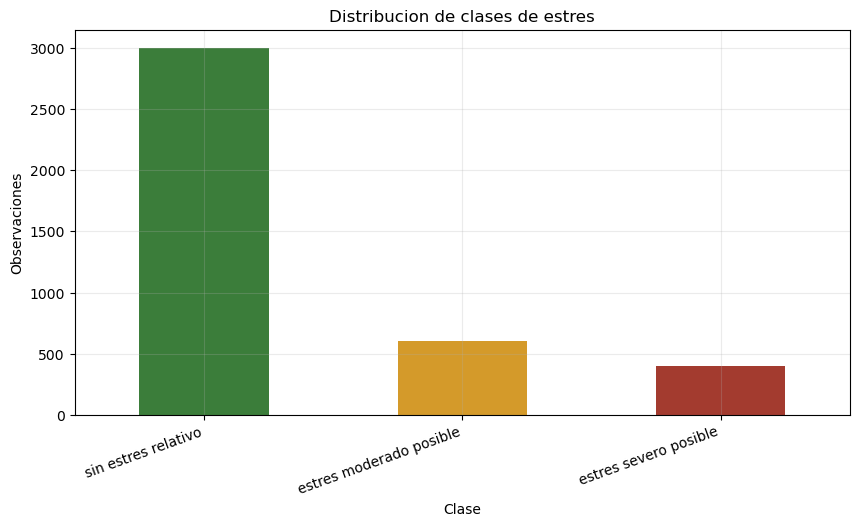

In [3]:
# Normalizacion ligera de nombres y fechas para que el resto del notebook sea estable.
df = df.copy()
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
if 'name' not in df.columns and 'parcela' in df.columns:
    df = df.rename(columns={'parcela': 'name'})

label_map = {
    0: 'sin estres relativo',
    1: 'estres moderado posible',
    2: 'estres severo posible',
}

required = {'name', 'stress_label'}
missing_required = required - set(df.columns)
if missing_required:
    raise ValueError(f'Faltan columnas requeridas: {missing_required}')

print('Parcelas unicas:', df['name'].nunique())
if 'date' in df.columns:
    print('Rango temporal:', df['date'].min().date(), 'a', df['date'].max().date())

class_counts = df['stress_label'].value_counts().sort_index().rename(index=label_map)
display(class_counts.to_frame('conteo'))

ax = class_counts.plot(kind='bar', color=['#3b7d3a', '#d49a2a', '#a33b2f'])
ax.set_title('Distribucion de clases de estres')
ax.set_xlabel('Clase')
ax.set_ylabel('Observaciones')
plt.xticks(rotation=20, ha='right')
plt.show()

## 3. Formulacion del baseline

**Tipo de problema:** clasificacion multiclase (`sin estres relativo`, `estres moderado posible`, `estres severo posible`) sobre registros parcela-mes.

**Por que regresion logistica multinomial como baseline:**

- Es simple, interpretable y de bajo costo computacional.
- Funciona bien con datos tabulares de indices espectrales e ingenieria temporal.
- Permite pesos por clase para mitigar el desbalance.
- Sus coeficientes permiten una primera lectura de relevancia de variables.
- Sirve como marco de referencia antes de invertir en CNN multiescala, modelos temporales, SAM2 o DINO.

**Comparador ingenuo:** `DummyClassifier(strategy='stratified')`, que predice respetando la distribucion historica de clases. Si el baseline no supera a este comparador, el problema o las etiquetas no tienen suficiente senal para justificar modelos mas complejos.

In [4]:
TARGET = 'stress_label'
ID_COLS = {'name', 'date', 'stress_class', TARGET}

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in ID_COLS]

X = df[feature_cols]
y = df[TARGET].astype(int)
groups = df['name'].astype(str)

print(f'Numero de caracteristicas: {len(feature_cols)}')
print(feature_cols)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

print('Train:', X_train.shape, 'parcelas:', g_train.nunique())
print('Test :', X_test.shape, 'parcelas:', g_test.nunique())
print('Interseccion de parcelas train/test:', len(set(g_train) & set(g_test)))

Numero de caracteristicas: 32
['year', 'month', 'NDMI_sc', 'NDMI_roll3_sc', 'NDVI_sc', 'NDVI_roll3_sc', 'NDMI_lag2_sc', 'NDVI_lag1_sc', 'mes_sin_sc', 'NDVI_lag2_sc', 'ratio_vi_hum_log_sc', 'lat_kml_sc', 'mes_cos_sc', 'image_count_sc', 'lon_kml_sc', 'NDMI_delta_yj_sc', 'NDVI_delta_yj_sc', 'NDWI_proxy_sc', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'FA1', 'FA2', 'FA3', 'FA4', 'FA5']
Train: (3000, 32) parcelas: 75
Test : (1000, 32) parcelas: 25
Interseccion de parcelas train/test: 0


,modelo,f1_macro,balanced_accuracy,recall_severo
0,dummy_stratified_test,0.343601,0.345641,0.11
1,baseline_train,0.987444,0.994707,1.00
2,baseline_test,0.984594,0.988846,0.98


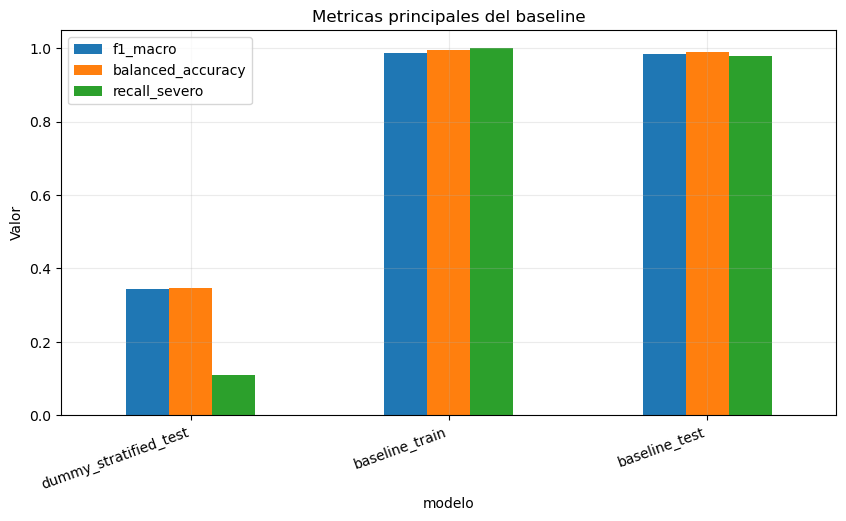

In [5]:
baseline_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        solver='lbfgs',
        multi_class='auto',
        random_state=42,
    )),
])

dummy_model = DummyClassifier(strategy='stratified', random_state=42)

baseline_model.fit(X_train, y_train)
dummy_model.fit(X_train, y_train)

pred_train = baseline_model.predict(X_train)
pred_test = baseline_model.predict(X_test)
pred_dummy = dummy_model.predict(X_test)

classes_present = sorted(y.unique())

def metric_row(name, y_true, y_pred):
    return {
        'modelo': name,
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'recall_severo': recall_score(y_true, y_pred, labels=[2], average='macro', zero_division=0),
    }

metrics = pd.DataFrame([
    metric_row('dummy_stratified_test', y_test, pred_dummy),
    metric_row('baseline_train', y_train, pred_train),
    metric_row('baseline_test', y_test, pred_test),
])
display(metrics)

ax = metrics.set_index('modelo')[['f1_macro', 'balanced_accuracy', 'recall_severo']].plot(kind='bar')
ax.set_title('Metricas principales del baseline')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor')
plt.xticks(rotation=20, ha='right')
plt.show()

## 4. Metrica de negocio y desempeno minimo

La metrica principal es **F1 macro**, porque cada clase pesa igual aunque el dataset este desbalanceado. En el contexto agricola, clasificar bien la clase mayoritaria no basta: interesa recuperar los casos de estres moderado y severo para priorizar revision de riego, inspeccion de campo o recomendaciones.

Metricas complementarias:

- **Balanced accuracy:** promedio de recall por clase; evita que la clase mayoritaria oculte fallas.
- **Recall severo:** mide que tanto se detecta el estres severo posible. Un falso negativo severo puede implicar perdida de oportunidad para intervenir.

Criterio minimo propuesto para este baseline:

- Superar al `DummyClassifier` por al menos **0.20 puntos de F1 macro**.
- Obtener **F1 macro >= 0.60** en prueba.
- Obtener **recall severo >= 0.70** en prueba.

Estos umbrales son una primera referencia. Deben ajustarse cuando existan etiquetas de campo o costos reales de falsos positivos/falsos negativos.

In [6]:
dummy_f1 = metrics.loc[metrics['modelo'] == 'dummy_stratified_test', 'f1_macro'].iloc[0]
test_f1 = metrics.loc[metrics['modelo'] == 'baseline_test', 'f1_macro'].iloc[0]
test_recall_severe = metrics.loc[metrics['modelo'] == 'baseline_test', 'recall_severo'].iloc[0]

minimums = pd.DataFrame({
    'criterio': [
        'F1 macro >= dummy + 0.20',
        'F1 macro >= 0.60',
        'Recall severo >= 0.70',
    ],
    'valor_obtenido': [test_f1 - dummy_f1, test_f1, test_recall_severe],
    'umbral': [0.20, 0.60, 0.70],
})
minimums['cumple'] = minimums['valor_obtenido'] >= minimums['umbral']
display(minimums)

if minimums['cumple'].all():
    print('Conclusion: el baseline alcanza el desempeno minimo propuesto.')
else:
    print('Conclusion: el baseline NO alcanza todos los minimos; se requiere revisar datos, etiquetas o caracteristicas.')

,criterio,valor_obtenido,umbral,cumple
0,F1 macro >= dummy + 0.20,0.640993,0.2,True
1,F1 macro >= 0.60,0.984594,0.6,True
2,Recall severo >= 0.70,0.980000,0.7,True


Conclusion: el baseline alcanza el desempeno minimo propuesto.


## 5. Resultados detallados

Se revisa el reporte por clase y la matriz de confusion para identificar si el modelo falla mas en estres moderado, severo o en la clase mayoritaria.

Reporte de clasificacion - prueba
                         precision    recall  f1-score   support

    sin estres relativo       1.00      0.99      1.00       780
estres moderado posible       0.95      0.99      0.97       120
  estres severo posible       0.99      0.98      0.98       100

               accuracy                           0.99      1000
              macro avg       0.98      0.99      0.98      1000
           weighted avg       0.99      0.99      0.99      1000



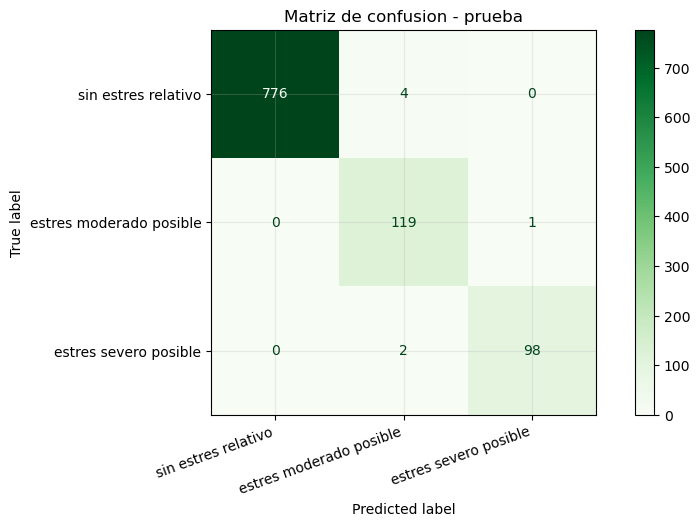

In [7]:
print('Reporte de clasificacion - prueba')
print(classification_report(
    y_test,
    pred_test,
    labels=classes_present,
    target_names=[label_map.get(c, str(c)) for c in classes_present],
    zero_division=0,
))

cm = confusion_matrix(y_test, pred_test, labels=classes_present)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[label_map.get(c, str(c)) for c in classes_present],
)
disp.plot(cmap='Greens', values_format='d')
plt.title('Matriz de confusion - prueba')
plt.xticks(rotation=20, ha='right')
plt.show()

## 6. Validacion cruzada por parcela

La particion usa grupos por `name` para que una misma parcela no aparezca simultaneamente en entrenamiento y prueba. Esto hace mas exigente la evaluacion, porque mide si el modelo generaliza a parcelas no vistas en lugar de memorizar patrones especificos de cada parcela.

,split,metric,mean,std
test_f1_macro,test,f1_macro,0.981652,0.010189
train_f1_macro,train,f1_macro,0.988139,0.001026
test_balanced_accuracy,test,balanced_accuracy,0.990919,0.004383
train_balanced_accuracy,train,balanced_accuracy,0.995351,0.000592
test_recall_severo,test,recall_severo,0.994707,0.007557
train_recall_severo,train,recall_severo,0.999390,0.001363


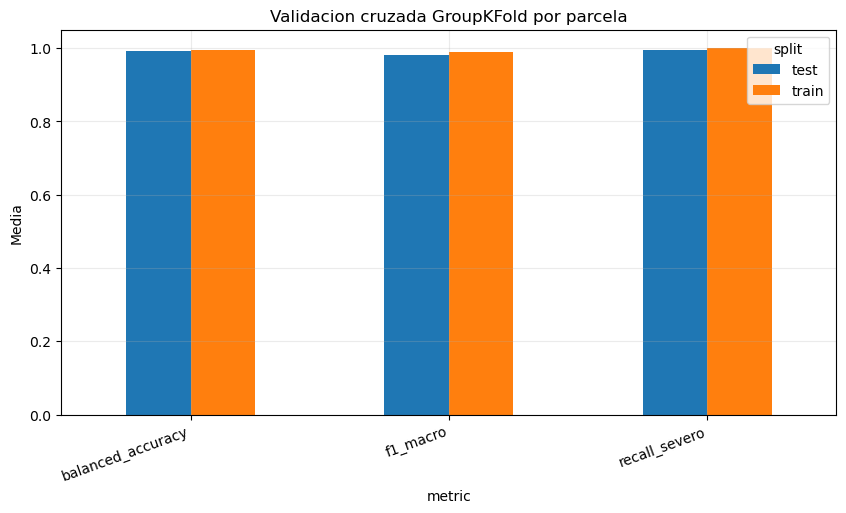

In [8]:
n_groups = groups.nunique()
n_splits = min(5, n_groups)
cv = GroupKFold(n_splits=n_splits)

scoring = {
    'f1_macro': make_scorer(f1_score, average='macro'),
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'recall_severo': make_scorer(recall_score, labels=[2], average='macro', zero_division=0),
}

cv_results = cross_validate(
    baseline_model,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=None,
)

cv_summary = pd.DataFrame(cv_results).filter(regex='train_|test_').agg(['mean', 'std']).T
cv_summary['metric'] = cv_summary.index.str.replace('train_', '').str.replace('test_', '')
cv_summary['split'] = np.where(cv_summary.index.str.startswith('train_'), 'train', 'test')
display(cv_summary[['split', 'metric', 'mean', 'std']])

plot_cv = cv_summary.reset_index(drop=True).pivot(index='metric', columns='split', values='mean')
ax = plot_cv.plot(kind='bar')
ax.set_ylim(0, 1.05)
ax.set_title('Validacion cruzada GroupKFold por parcela')
ax.set_ylabel('Media')
plt.xticks(rotation=20, ha='right')
plt.show()

## 7. Diagnostico de subajuste / sobreajuste

Se comparan entrenamiento y prueba. Si el entrenamiento es muy alto y la prueba cae de manera fuerte, hay senal de sobreajuste. Si ambos son bajos, hay subajuste o baja senal en los datos. Tambien se calcula una curva de aprendizaje aumentando el numero de parcelas de entrenamiento.

,fraccion_parcelas_train,n_parcelas_train,f1_macro_train,f1_macro_test
0,0.2,15,0.981666,0.930179
1,0.4,30,0.988521,0.981345
2,0.6,45,0.988168,0.983075
3,0.8,60,0.988863,0.975548
4,1.0,75,0.987444,0.984594


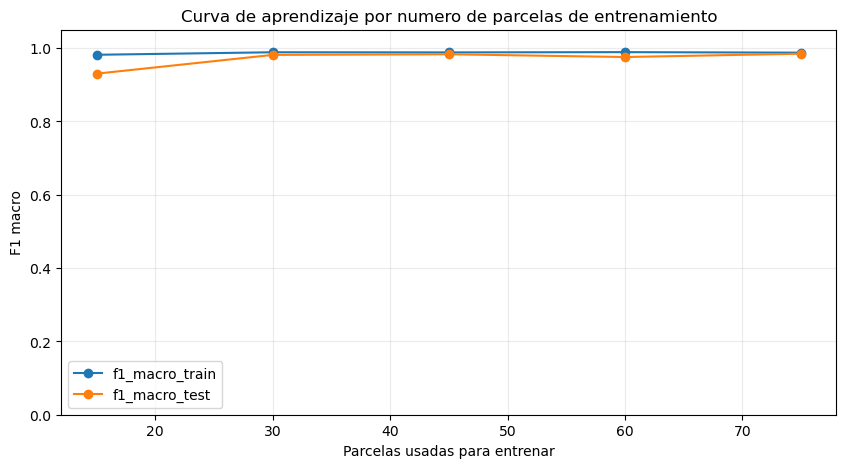

Brecha train-test F1 macro: 0.003
Lectura: no se observa una brecha fuerte de sobreajuste bajo este split.


In [9]:
# Curva de aprendizaje manual por grupos de parcelas.
rng = np.random.default_rng(42)
unique_train_groups = np.array(sorted(g_train.unique()))
fractions = np.linspace(0.2, 1.0, 5)
learning_rows = []

for frac in fractions:
    n_pick = max(2, int(round(len(unique_train_groups) * frac)))
    picked_groups = rng.choice(unique_train_groups, size=n_pick, replace=False)
    mask = g_train.isin(picked_groups).to_numpy()
    model = clone(baseline_model)
    model.fit(X_train.loc[mask], y_train.loc[mask])
    tr_pred = model.predict(X_train.loc[mask])
    te_pred = model.predict(X_test)
    learning_rows.append({
        'fraccion_parcelas_train': frac,
        'n_parcelas_train': n_pick,
        'f1_macro_train': f1_score(y_train.loc[mask], tr_pred, average='macro'),
        'f1_macro_test': f1_score(y_test, te_pred, average='macro'),
    })

learning_curve_df = pd.DataFrame(learning_rows)
display(learning_curve_df)

ax = learning_curve_df.plot(
    x='n_parcelas_train',
    y=['f1_macro_train', 'f1_macro_test'],
    marker='o',
)
ax.set_title('Curva de aprendizaje por numero de parcelas de entrenamiento')
ax.set_xlabel('Parcelas usadas para entrenar')
ax.set_ylabel('F1 macro')
ax.set_ylim(0, 1.05)
plt.show()

gap = metrics.loc[metrics['modelo'] == 'baseline_train', 'f1_macro'].iloc[0] - test_f1
print(f'Brecha train-test F1 macro: {gap:.3f}')
if gap > 0.15:
    print('Lectura: posible sobreajuste; conviene regularizar mas, reducir caracteristicas o validar etiquetas.')
elif test_f1 < 0.60:
    print('Lectura: posible subajuste o senal insuficiente para el objetivo actual.')
else:
    print('Lectura: no se observa una brecha fuerte de sobreajuste bajo este split.')

## 8. Importancia de caracteristicas

Se combinan dos lecturas:

- **Coeficientes absolutos promedio** de la regresion logistica: interpretacion embedded del modelo lineal.
- **Permutation importance** en prueba: cuanto cae el desempeno cuando se rompe una caracteristica.

Esto permite detectar variables dominantes, redundantes o candidatas a eliminacion antes de pasar a modelos mas complejos.

,coef_abs_promedio
ratio_vi_hum_log_sc,2.118345
NDMI_sc,1.920737
PC7,1.870084
PC6,1.750757
FA2,1.635367
PC5,1.569830
NDMI_roll3_sc,1.431755
FA1,1.184387
NDVI_sc,1.076973
PC1,0.907225


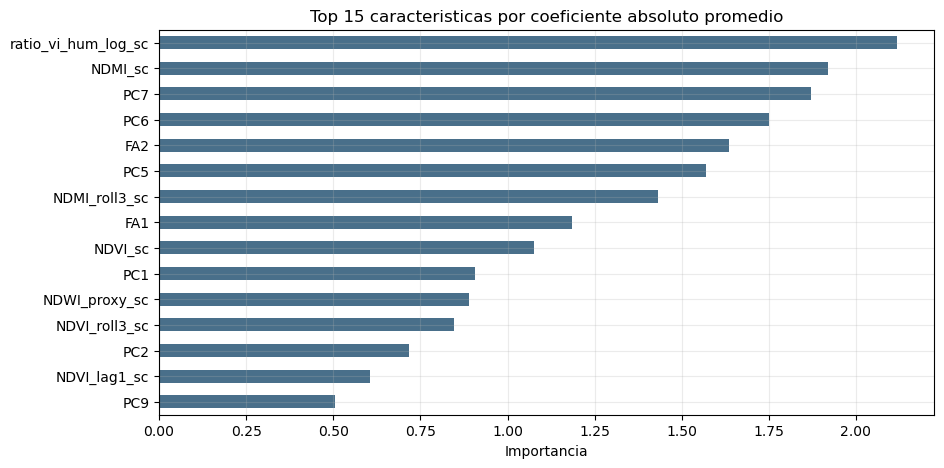

In [10]:
clf = baseline_model.named_steps['clf']
coef_importance = pd.Series(
    np.abs(clf.coef_).mean(axis=0),
    index=feature_cols,
    name='coef_abs_promedio',
).sort_values(ascending=False)

display(coef_importance.head(15).to_frame())

ax = coef_importance.head(15).sort_values().plot(kind='barh', color='#496f8a')
ax.set_title('Top 15 caracteristicas por coeficiente absoluto promedio')
ax.set_xlabel('Importancia')
plt.show()

,feature,importance_mean,importance_std
2,NDMI_sc,0.146996,0.009377
24,PC7,0.112806,0.005779
10,ratio_vi_hum_log_sc,0.099983,0.010838
3,NDMI_roll3_sc,0.096717,0.013862
22,PC5,0.091730,0.012644
23,PC6,0.083651,0.007067
27,FA1,0.073077,0.007987
28,FA2,0.067497,0.014891
4,NDVI_sc,0.064070,0.006762
18,PC1,0.053495,0.007242


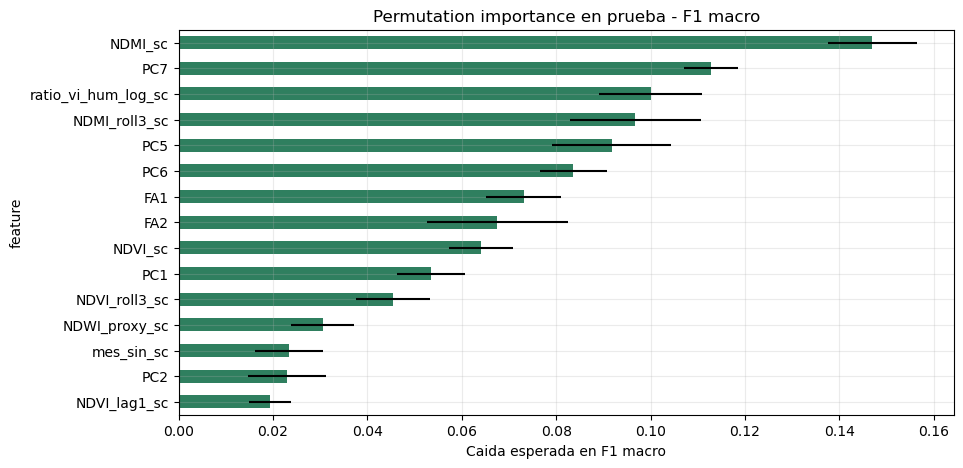

In [11]:
perm = permutation_importance(
    baseline_model,
    X_test,
    y_test,
    scoring=make_scorer(f1_score, average='macro'),
    n_repeats=10,
    random_state=42,
)
perm_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

display(perm_importance.head(15))

ax = perm_importance.head(15).sort_values('importance_mean').plot(
    x='feature',
    y='importance_mean',
    kind='barh',
    xerr='importance_std',
    color='#2f7f5f',
    legend=False,
)
ax.set_title('Permutation importance en prueba - F1 macro')
ax.set_xlabel('Caida esperada en F1 macro')
plt.show()

## 9. Revision de imagenes Sentinel-2 locales

El baseline principal usa datos tabulares por parcela-mes. Aun asi, se revisa si existen GeoTIFFs locales para conectar este avance con la arquitectura de vision computacional. Esta celda no requiere `rasterio`; si esta instalado, muestra metadatos basicos de las imagenes.

In [12]:
geotiffs = sorted(GEOTIFF_DIR.glob('*.tif')) if GEOTIFF_DIR.exists() else []
print(f'GeoTIFFs encontrados en {GEOTIFF_DIR}: {len(geotiffs)}')
for p in geotiffs[:10]:
    print('-', p.name, f'{p.stat().st_size / (1024**2):.1f} MB')

try:
    import rasterio
    rows = []
    for p in geotiffs[:10]:
        with rasterio.open(p) as src:
            rows.append({
                'archivo': p.name,
                'bandas': src.count,
                'alto': src.height,
                'ancho': src.width,
                'crs': str(src.crs),
                'dtype': ', '.join(sorted(set(src.dtypes))),
            })
    if rows:
        display(pd.DataFrame(rows))
except Exception as exc:
    print('rasterio no esta disponible o no pudo abrir los archivos. Se omite inspeccion raster detallada.')
    print(type(exc).__name__, exc)

GeoTIFFs encontrados en C:\Users\YOLOA\OneDrive\Desktop\Repo Proyecto Integrador\Avocado AI\notebooks\data\geotiff: 3
- level2_priority_avocado_stack_2023_04.tif 2.2 MB
- level2_priority_avocado_stack_2024_04.tif 2.1 MB
- level2_priority_avocado_stack_2025_04.tif 2.2 MB
rasterio no esta disponible o no pudo abrir los archivos. Se omite inspeccion raster detallada.
ModuleNotFoundError No module named 'rasterio'


### Visualizacion exploratoria de Sentinel-2

Los archivos `level2_priority_avocado_stack_2023_04.tif`, `2024_04.tif` y `2025_04.tif` representan stacks locales de Sentinel-2 para la parcela/zona de interes. La visualizacion siguiente replica el espiritu de los notebooks previos: revisar composiciones por fecha antes de modelar.

Se asume el orden de bandas propuesto en la arquitectura: **B2, B3, B4, B8, B8A, B11, B12**. Con ello se generan:

- **RGB natural:** B4, B3, B2.
- **Falso color NIR:** B8, B4, B3, util para vegetacion.
- **NDVI aproximado:** (B8 - B4) / (B8 + B4).
- **NDMI aproximado:** (B8 - B11) / (B8 + B11), indicador relacionado con humedad/estres hidrico.

Si las bandas ya vienen normalizadas o transformadas, estas imagenes deben interpretarse como diagnostico visual, no como producto agronomico final.

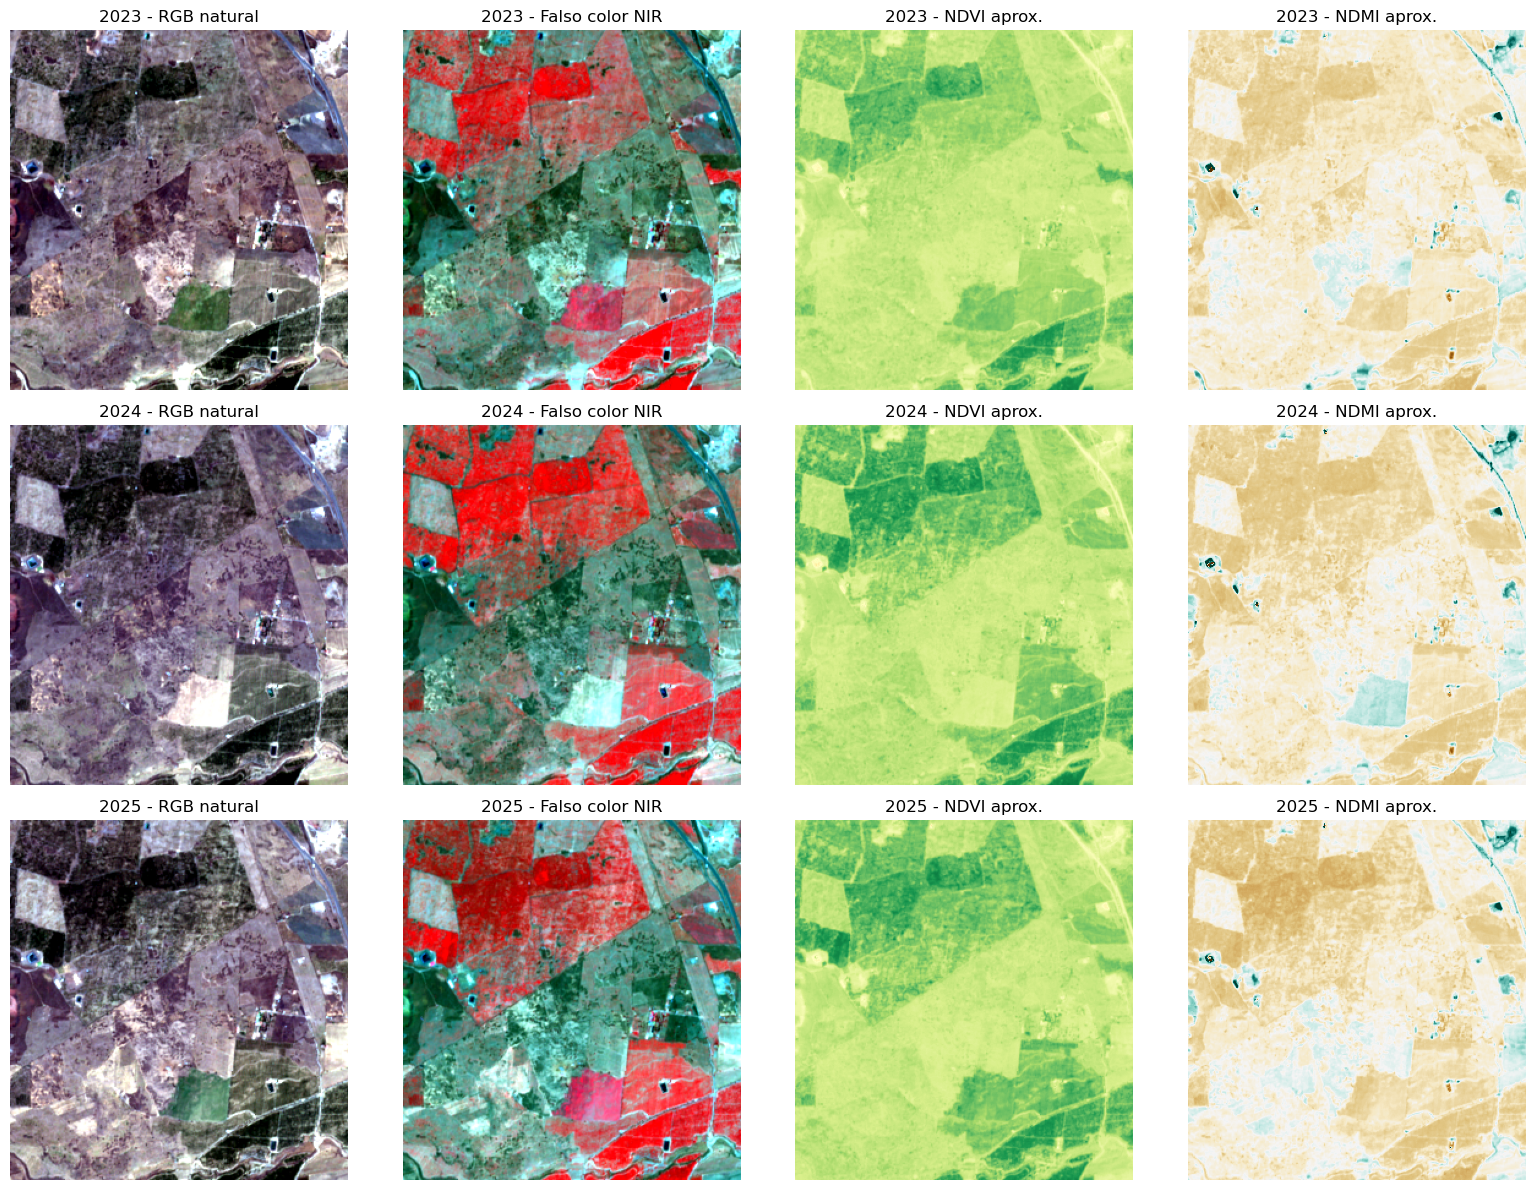

,archivo,alto,ancho,canales,min,max,media
0,level2_priority_avocado_stack_2023_04.tif,294,276,7,-0.657280,0.888161,0.143981
1,level2_priority_avocado_stack_2024_04.tif,294,276,7,-0.670285,0.937228,0.158840
2,level2_priority_avocado_stack_2025_04.tif,294,276,7,-0.613097,0.904603,0.156839


In [13]:
def percentile_stretch(arr, low=2, high=98):
    arr = np.asarray(arr, dtype='float32')
    out = np.zeros_like(arr, dtype='float32')
    if arr.ndim == 2:
        lo, hi = np.nanpercentile(arr, [low, high])
        return np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)
    for band in range(arr.shape[-1]):
        lo, hi = np.nanpercentile(arr[..., band], [low, high])
        out[..., band] = np.clip((arr[..., band] - lo) / (hi - lo + 1e-6), 0, 1)
    return out


def safe_index(numerator, denominator):
    return numerator / (denominator + 1e-6)


def read_geotiff_array(path):
    try:
        import tifffile
        return tifffile.imread(path)
    except Exception:
        from PIL import Image
        return np.asarray(Image.open(path))

if geotiffs:
    fig, axes = plt.subplots(len(geotiffs), 4, figsize=(16, 4 * len(geotiffs)))
    if len(geotiffs) == 1:
        axes = np.expand_dims(axes, axis=0)

    summary_rows = []
    for row, tif_path in enumerate(geotiffs):
        stack = read_geotiff_array(tif_path)
        if stack.ndim == 2:
            stack = stack[..., np.newaxis]
        if stack.shape[0] <= 12 and stack.ndim == 3 and stack.shape[-1] > 12:
            stack = np.moveaxis(stack, 0, -1)

        year = tif_path.stem.split('_')[-2] if '_' in tif_path.stem else tif_path.stem
        summary_rows.append({
            'archivo': tif_path.name,
            'alto': stack.shape[0],
            'ancho': stack.shape[1],
            'canales': stack.shape[2],
            'min': float(np.nanmin(stack)),
            'max': float(np.nanmax(stack)),
            'media': float(np.nanmean(stack)),
        })

        if stack.shape[2] >= 7:
            b2, b3, b4, b8, b8a, b11, b12 = [stack[..., i] for i in range(7)]
            rgb = percentile_stretch(np.dstack([b4, b3, b2]))
            false_color = percentile_stretch(np.dstack([b8, b4, b3]))
            ndvi = safe_index(b8 - b4, b8 + b4)
            ndmi = safe_index(b8 - b11, b8 + b11)
        else:
            rgb = percentile_stretch(stack[..., :min(3, stack.shape[2])])
            if rgb.shape[-1] == 1:
                rgb = np.repeat(rgb, 3, axis=-1)
            false_color = rgb
            ndvi = stack[..., 0]
            ndmi = stack[..., 0]

        axes[row, 0].imshow(rgb)
        axes[row, 0].set_title(f'{year} - RGB natural')
        axes[row, 1].imshow(false_color)
        axes[row, 1].set_title(f'{year} - Falso color NIR')
        im_ndvi = axes[row, 2].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
        axes[row, 2].set_title(f'{year} - NDVI aprox.')
        im_ndmi = axes[row, 3].imshow(ndmi, cmap='BrBG', vmin=-1, vmax=1)
        axes[row, 3].set_title(f'{year} - NDMI aprox.')

        for ax in axes[row]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()
    display(pd.DataFrame(summary_rows))
else:
    print('No se encontraron GeoTIFFs locales para visualizar.')

## 10. Extension futura: SAM2, DINO y CNN multiescala

SAM2/DINO no se ejecutan en este avance porque el objetivo evaluado es construir un baseline reproducible, interpretable y de bajo costo computacional. Se documentan solo como ruta tecnica posterior: usar CNN multiescala sobre parches Sentinel-2 de 10 canales, SAM2 para apoyar mascaras/segmentacion de parcelas y DINO/DINOv2 para extraer embeddings visuales de composiciones RGB o falso color.

Cualquier modelo avanzado debera compararse contra este baseline usando la misma particion por parcela y las mismas metricas (`F1 macro`, `balanced_accuracy` y `recall severo`).

In [14]:
USE_FOUNDATION_MODELS = False

if USE_FOUNDATION_MODELS:
    print('Aqui se conectaria SAM2/DINO si las dependencias y pesos ya existen localmente.')
    print('Mantener en False para que la libreta del Avance 3 sea reproducible sin internet/GPU.')
else:
    print('SAM2/DINO documentados como extension futura; no se ejecutan en el baseline secuencial.')

SAM2/DINO documentados como extension futura; no se ejecutan en el baseline secuencial.


## 11. Conclusiones del baseline

Despues de ejecutar la libreta de principio a fin, el baseline obtiene:

- **F1 macro en prueba:** 0.9846, frente a 0.3436 del `DummyClassifier`.
- **Balanced accuracy en prueba:** 0.9888.
- **Recall de estres severo:** 0.9800.
- **Brecha train-test en F1 macro:** 0.003, sin evidencia fuerte de sobreajuste bajo la particion por parcela.

Con estos resultados, el baseline supera el desempeno minimo propuesto: mejora al dummy por mas de 0.20 puntos de F1 macro, rebasa F1 macro >= 0.60 y alcanza recall severo >= 0.70.

La interpretacion debe ser cuidadosa: el desempeno alto confirma que las caracteristicas espectrales y temporales contienen senal suficiente para reproducir las etiquetas proxy de estres. Sin embargo, como estas etiquetas parecen derivarse de indices satelitales, no debe interpretarse todavia como validacion agronomica completa. El siguiente paso recomendado es comparar modelos alternativos con la misma metodologia y, cuando sea posible, validar contra datos independientes de campo, riego, humedad de suelo o diagnostico experto.